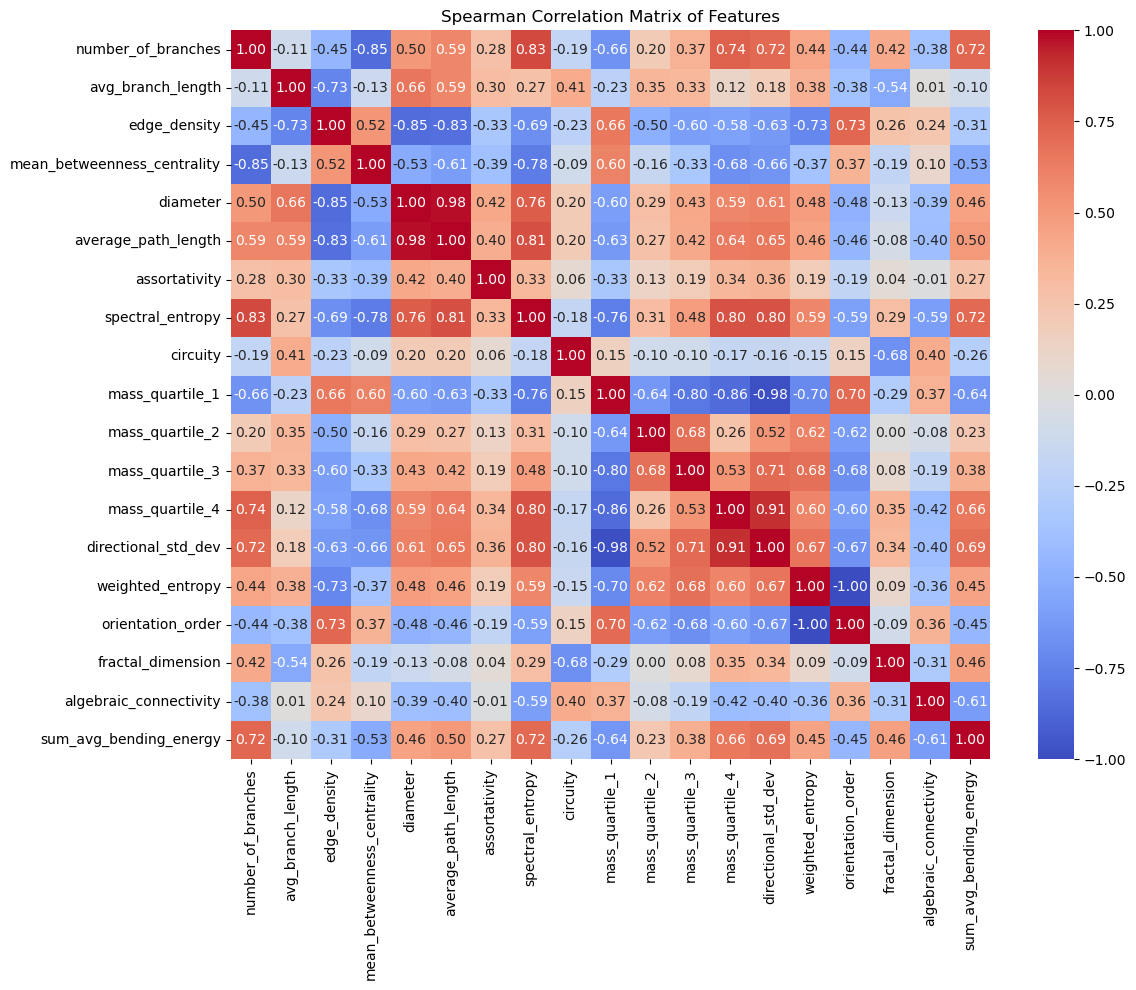

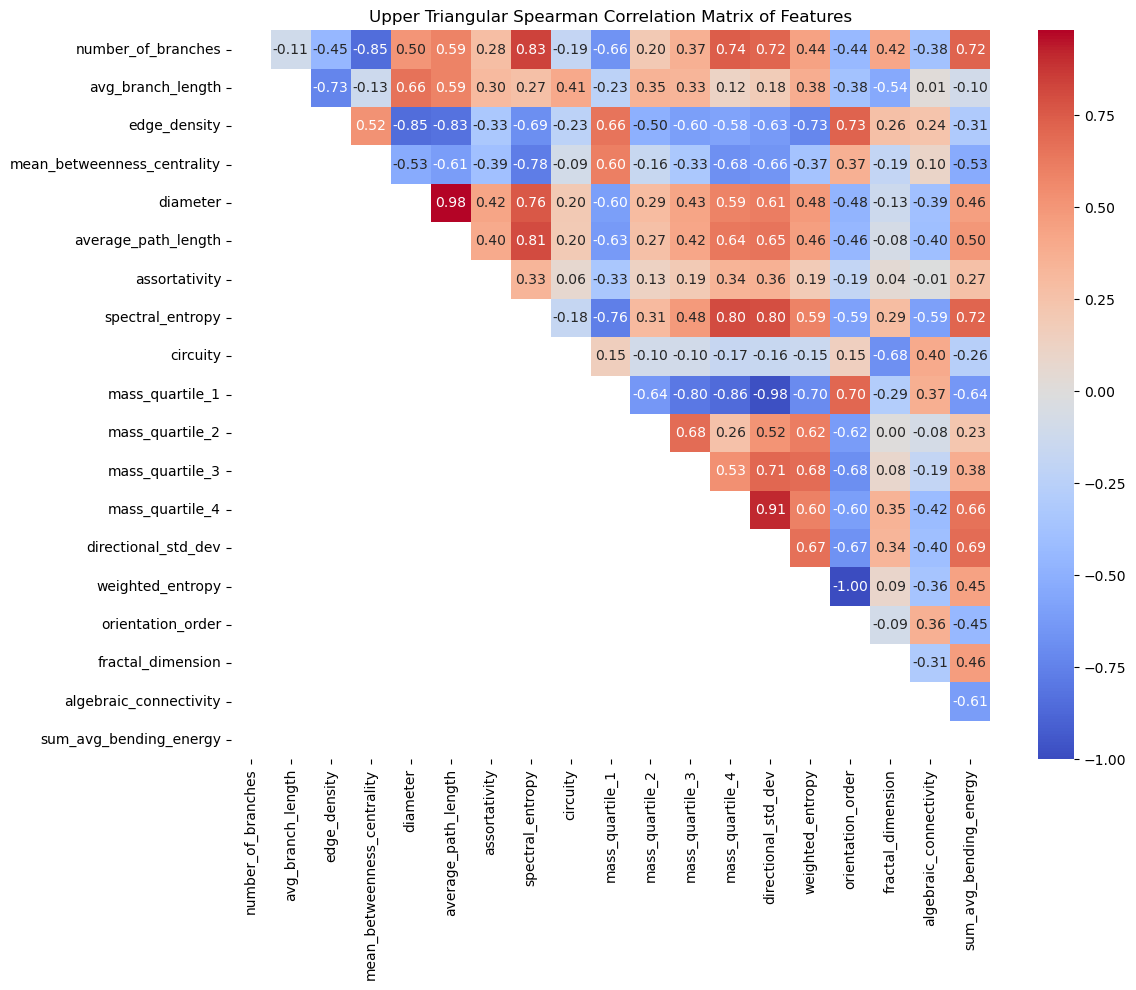

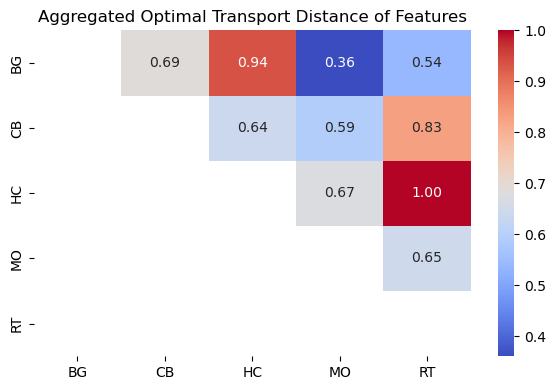

In [5]:
%matplotlib inline
import os
import math
import numpy as np
import networkx as nx
from scipy.spatial import ConvexHull
from scipy import linalg
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ot
import porespy as ps
from skimage import draw
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler



# Define folders and features (same as original)
folders = ['Basal_ganglia', 'Cerebellum', 'Hippocampus', 'Main_olfactory_bulb', 'Retina']
label_map = {folder: idx for idx, folder in enumerate(folders)}
feature_names = [
    'number_of_branches', 'avg_branch_length', 'edge_density', 'mean_betweenness_centrality',
    'diameter', 'average_path_length', 'assortativity', 'spectral_entropy', 'circuity',
    'mass_quartile_1', 'mass_quartile_2', 'mass_quartile_3', 'mass_quartile_4',
    'directional_std_dev', 'weighted_entropy', 'orientation_order', 'fractal_dimension',
    'algebraic_connectivity', 'sum_avg_bending_energy'
]

# Load from CSV
df = pd.read_csv('neuron_features.csv')

# Reconstruct feature_data from CSV
feature_data = {feature: {folder: [] for folder in folders} for feature in feature_names}
for folder, label in label_map.items():
    folder_df = df[df['label'] == label]
    for feature in feature_names:
        feature_data[feature][folder] = folder_df[feature].tolist()

# Apply Min-Max normalization to features where max > 1 (same as original)
scaler = MinMaxScaler()
for feat_name in feature_names:
    all_values = []
    for folder in folders:
        all_values.extend(feature_data[feat_name][folder])
    all_values = np.array(all_values)
    if len(all_values) > 0 and np.max(all_values) > 1:
        all_values_reshaped = all_values.reshape(-1, 1)
        normalized_values = scaler.fit_transform(all_values_reshaped).flatten()
        start_idx = 0
        for folder in folders:
            num_values = len(feature_data[feat_name][folder])
            feature_data[feat_name][folder] = normalized_values[start_idx:start_idx + num_values].tolist()
            start_idx += num_values

# Compute Spearman correlation matrix (same as original)
num_features = len(feature_names)
conc_feature_for_corr = []
for folder in folders:
    folder_features = np.array([
        feature_data[feat][folder] for feat in feature_names
    ]).T
    conc_feature_for_corr.append(folder_features)
conc_feature_for_corr = np.vstack(conc_feature_for_corr)
corr_matrix = np.zeros((num_features, num_features))
for i in range(num_features):
    for j in range(num_features):
        corr_index, _ = spearmanr(conc_feature_for_corr[:, i], conc_feature_for_corr[:, j], nan_policy='omit')
        corr_matrix[i, j] = corr_index if not np.isnan(corr_index) else 0

# (Optional) Plot full correlation matrix heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", xticklabels=feature_names, yticklabels=feature_names)
plt.title("Spearman Correlation Matrix of Features")
plt.savefig('Spearman Correlation Matrix of Features.png', dpi=300)
plt.tight_layout()
plt.show()

# (Optional) Plot upper triangular correlation matrix heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_matrix_upper = np.where(mask, corr_matrix, np.nan)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_upper, annot=True, cmap='coolwarm', fmt=".2f", xticklabels=feature_names, yticklabels=feature_names)
plt.title("Upper Triangular Spearman Correlation Matrix of Features")
plt.savefig('Upper Triangular Spearman Correlation Matrix of Features.png', dpi=300)
plt.tight_layout()
plt.show()

# Compute OT distances for each feature (same as original)
def compute_ot_distance_1d(data1, data2):
    n_bins = max(len(data1), len(data2))
    bins = np.linspace(min(min(data1), min(data2)), max(max(data1), max(data2)), n_bins)
    hist1, _ = np.histogram(data1, bins=bins, density=True)
    hist2, _ = np.histogram(data2, bins=bins, density=True)
    hist1 = hist1 / np.sum(hist1)
    hist2 = hist2 / np.sum(hist2)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    M = ot.dist(bin_centers.reshape(-1, 1), bin_centers.reshape(-1, 1), metric='euclidean')
    return ot.emd2(hist1, hist2, M)

# If 'ot' is not available, uncomment this version using scipy:
# from scipy.stats import wasserstein_distance
# def compute_ot_distance_1d(data1, data2):
#     if not data1 or not data2:
#         return 0.0
#     n_bins = max(len(data1), len(data2))
#     min_val = min(min(data1), min(data2))
#     max_val = max(max(data1), max(data2))
#     if min_val == max_val:
#         return 0.0
#     bins = np.linspace(min_val, max_val, n_bins)
#     hist1, _ = np.histogram(data1, bins=bins, density=True)
#     hist2, _ = np.histogram(data2, bins=bins, density=True)
#     hist1 /= np.sum(hist1) if np.sum(hist1) > 0 else 1
#     hist2 /= np.sum(hist2) if np.sum(hist2) > 0 else 1
#     bin_centers = (bins[:-1] + bins[1:]) / 2
#     return wasserstein_distance(bin_centers, bin_centers, hist1, hist2)

distance_matrix_all_features = np.zeros((num_features, 5, 5))
for feat_idx, feat_name in enumerate(feature_names):
    for i, folder1 in enumerate(folders):
        for j, folder2 in enumerate(folders):
            data1 = feature_data[feat_name][folder1]
            data2 = feature_data[feat_name][folder2]
            if len(data1) > 0 and len(data2) > 0:
                dist = compute_ot_distance_1d(data1, data2)
                distance_matrix_all_features[feat_idx, i, j] = dist if not np.isnan(dist) else 0

# Aggregated OT distance (same as original)
I_n = np.eye(num_features)
tot_distance_matrix = np.zeros((5, 5))
for i in range(num_features):
    single_feat_distance_matrix = distance_matrix_all_features[i, :, :]
    for k in range(5):
        for l in range(5):
            dist_single_feature = single_feat_distance_matrix[k, l]
            for j in range(i, num_features):
                dist_single_feat_vs_rest = distance_matrix_all_features[j, k, l]
                value = I_n[i, j] - ((1/num_features) * np.abs(corr_matrix[i, j] - I_n[i, j]))
                tot_distance_matrix[k, l] += dist_single_feature * value * dist_single_feat_vs_rest

# Apply square root transformation
tot_distance_matrix = np.sqrt(tot_distance_matrix)

# Normalize to make the maximum value 1.0
max_dist = np.nanmax(tot_distance_matrix)
if max_dist > 0:
    tot_distance_matrix /= max_dist

# Define renamed labels
new_labels = ['BG', 'CB', 'HC', 'MO', 'RT']

# Create upper triangular matrix for visualization
def upper_triangular(df):
    mask = np.triu(np.ones(df.shape), k=1).astype(bool)
    df_upper = df.where(mask)
    return df_upper

df_distances = pd.DataFrame(tot_distance_matrix, index=new_labels, columns=new_labels)
df_distances_upper = upper_triangular(df_distances)

# Plot OT distance heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df_distances_upper, annot=True, cmap='coolwarm', fmt=".2f", mask=df_distances_upper.isnull())
plt.title("Aggregated Optimal Transport Distance of Features")

# plt.ylabel("Folder 1")
# plt.xlabel("Folder 2")
plt.tight_layout()
plt.savefig('aggregated_ot_distance.png', dpi=300)
plt.show()